<a href="https://colab.research.google.com/github/fedhere/DSPS_FBianco/blob/master/HW7/kmeans_example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pylab as pl
import sklearn.cluster
import time
import os
import urllib
%pylab inline
pl.style.use('ggplot')


Populating the interactive namespace from numpy and matplotlib


## generating random data:
## 2 gaussian distributions, differnt means, different stsndard deviations


9.8 6.5 1.1 1.4 


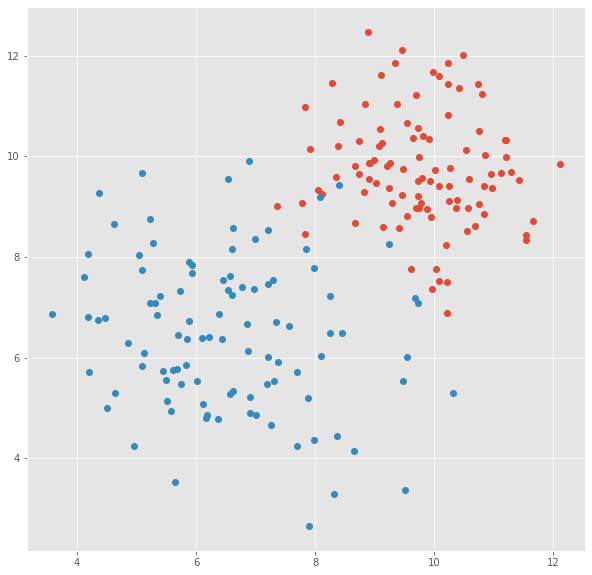

In [2]:

pl.figure(figsize = (10,10))
# seed for reporducibility
np.random.seed(1999)
#k1s, k1m = np.random.rand()*5, random.rand()*10 
##k2s, k2m = np.random.rand()*2.5, random.rand()*10
#
k1m, k2m, k1s, k2s = 9.8, 6.5, 1.1, 1.4
k1 = (k1s * np.random.randn(2, 100) + k1m).T
k2 = (k2s * np.random.randn(2, 100) + k2m).T
print ("{:.2} {:.2} {:.2} {:.2} ".format(k1m, k2m, k1s, k2s))
pl.plot(k1[:,0], k1[:,1], 'o')
pl.plot(k2[:,0], k2[:,1], 'o');



## choose 2 random starting points: random locations within the distribution


In [3]:
np.random.seed(315)
x1, y1 = (max(k1[:,0]) + (min(k1[:,0])) / 2) * np.random.rand(),\
      (max(k1[:,1]) + (min(k1[:,1])) / 2) * np.random.rand()
x2, y2 = (max(k2[:,0]) + (min(k2[:,0])) / 2)  * np.random.rand(),\
      (max(k2[:,1]) + (min(k2[:,1])) / 2) * np.random.rand()

the true centers are: 9.80 9.80 6.50 6.50


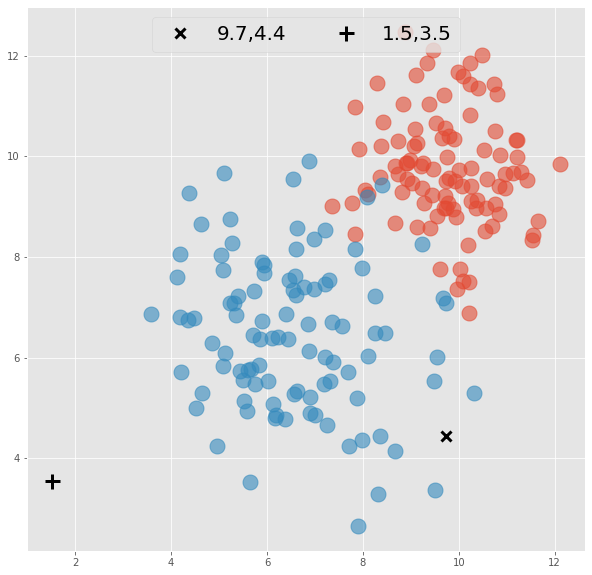

In [4]:
x_save = (x1,x2)
y_save = (y1,y2)

pl.figure(figsize = (10,10))
print ("the true centers are: {:.2f} {:.2f} {:.2f} {:.2f}".format(k1m, k1m, k2m, k2m,))
pl.plot(k1[:,0], k1[:,1], 'o', ms = 15, alpha=0.6)
pl.plot(k2[:,0], k2[:,1], 'o', ms = 15, alpha=0.6)

pl.plot([x1], [y1], 'kx', ms = 10, mew=3, label="%.1f,%.1f"%(x1,y1))
pl.plot([x2], [y2], 'k+', ms = 15, mew=3, label="%.1f,%.1f"%(x2,y2))
pl.legend(loc = 'upper center', ncol= 2, numpoints=1, fontsize=20)


## define a distance matric





In [5]:
#Eucledian distance
def dist (data, c):
    return (data[0]-c[0])**2 + (data[1]-c[1])**2


# calculate all distances

In [6]:
#l1 = np.zeros(len(k1), int)
#for i,k in enumerate(k1):
#    l1[i] = 0 if dist(k, [x1, y1]) < dist(k, [x2, y2]) else 1
#l2 = np.zeros(len(k2), int)
#for i,k in enumerate(k2):
#    l2[i] = 0 if dist(k, [x1, y1]) < dist(k, [x2, y2]) else 1

l1 = (dist(k1.T, (x1, y1)) < dist(k1.T, (x2, y2))).astype(int)
l2 = (dist(k2.T, (x1, y1)) < dist(k2.T, (x2, y2))).astype(int)

In [7]:
l1

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

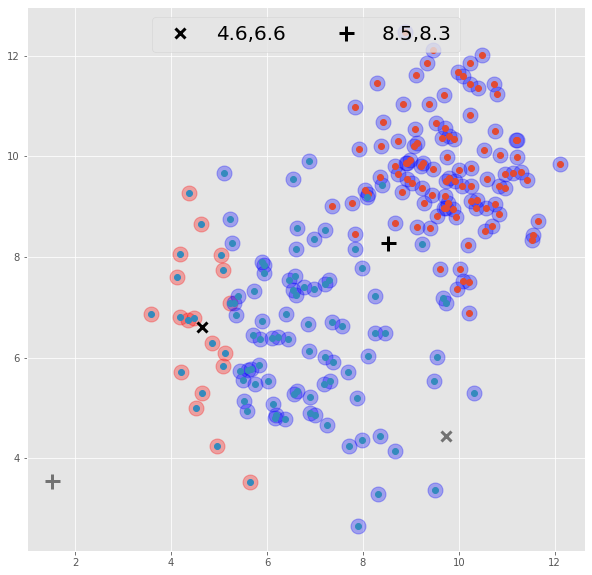

In [8]:
pl.figure(figsize = (10,10))

pl.plot([x1], [y1], 'kx', ms = 10, mew=3, alpha=0.5)
pl.plot([x2], [y2], 'k+', ms = 15, mew=3, alpha=0.5)

pl.plot(k1[l1==0][:,0], k1[l1==0][:,1], 'ro', ms=15, alpha = 0.3)
pl.plot(k2[l2==0][:,0], k2[l2==0][:,1], 'ro', ms=15, alpha = 0.3)
pl.plot(k1[l1==1][:,0], k1[l1==1][:,1], 'bo', ms=15, alpha = 0.3)
pl.plot(k2[l2==1][:,0], k2[l2==1][:,1], 'bo', ms=15, alpha = 0.3)
pl.plot(k1[:,0], k1[:,1], 'o')
pl.plot(k2[:,0], k2[:,1], 'o')

xnew1, ynew1 = np.mean(np.concatenate([k1[l1==0][:,0], k2[l2==0][:,0]])), \
              np.mean(np.concatenate([k1[l1==0][:,1], k2[l2==0][:,1]]))
xnew2, ynew2 = np.mean(np.concatenate([k1[l1==1][:,0], k2[l2==1][:,0]])), \
              np.mean(np.concatenate([k1[l1==1][:,1], k2[l2==1][:,1]]))

pl.plot([xnew1], [ynew1], 'kx', ms = 10, mew=3, label="%.1f,%.1f"%(xnew1,ynew1))
pl.plot([xnew2], [ynew2], 'k+', ms = 15, mew=3, label="%.1f,%.1f"%(xnew2,ynew2))
pl.legend(loc = 'upper center', ncol= 2, numpoints=1, fontsize=20)



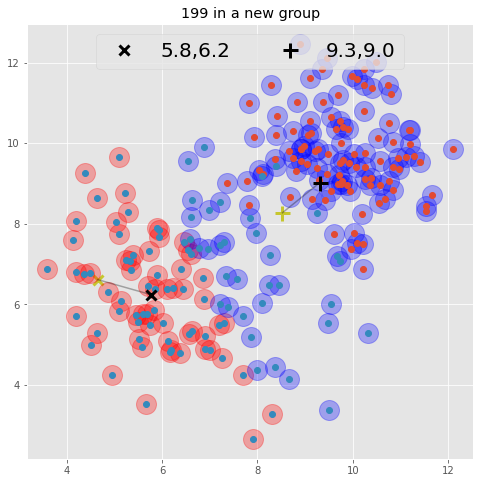

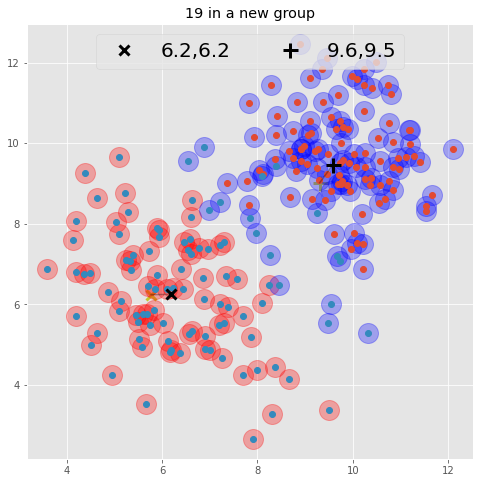

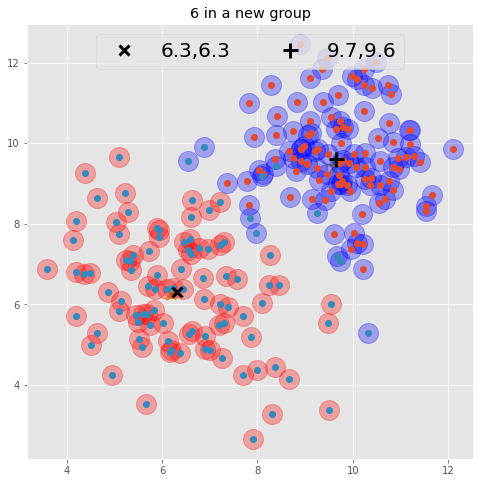

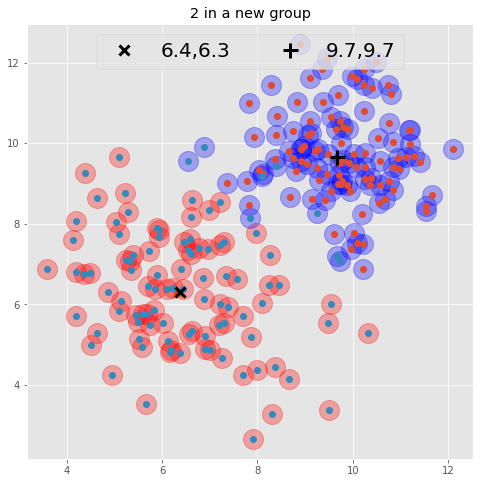

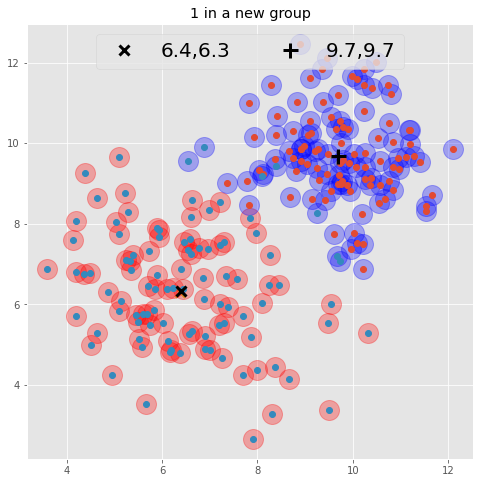

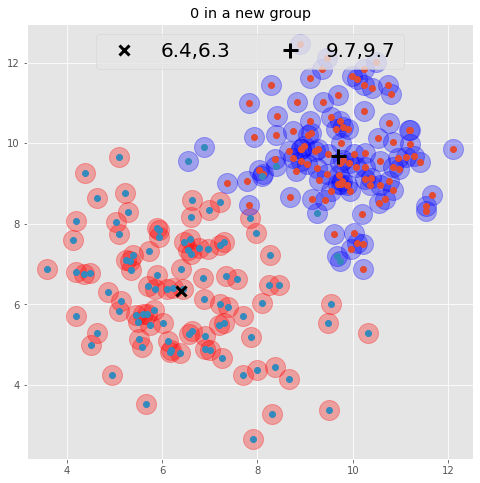

In [9]:
l1old = np.empty_like(l1)
l2old = np.empty_like(l2)


while not xnew1 == x1 or  not ynew1 == y1 or  not xnew2 == x2 or  not ynew2 == y2:
    time.sleep(2)
    pl.figure(figsize = (8,8))
    x1 = xnew1
    x2 = xnew2
    y1 = ynew1
    y2 = ynew2
    
    l1 = (dist(k1.T, (x1, y1)) > dist(k1.T, (x2, y2))).astype(int)
    l2 = (dist(k2.T, (x1, y1)) > dist(k2.T, (x2, y2))).astype(int)
        
    pl.plot([x1], [y1], 'yx', ms = 10, mew=3, alpha=0.8)
    pl.plot([x2], [y2], 'y+', ms = 15, mew=3, alpha=0.8)

    pl.plot(k1[l1==0][:,0], k1[l1==0][:,1], 'ro', ms=20, alpha = 0.3)
    pl.plot(k2[l2==0][:,0], k2[l2==0][:,1], 'ro', ms=20, alpha = 0.3)
    pl.plot(k1[l1==1][:,0], k1[l1==1][:,1], 'bo', ms=20, alpha = 0.3)
    pl.plot(k2[l2==1][:,0], k2[l2==1][:,1], 'bo', ms=20, alpha = 0.3)
    pl.plot(k1[:,0], k1[:,1], 'o')
    pl.plot(k2[:,0], k2[:,1], 'o')

    xnew1, ynew1 = np.mean(np.concatenate([k1[l1==0][:,0], 
                                       k2[l2==0][:,0]])), np.mean(np.concatenate([k1[l1==0][:,1], 
                                                                                  k2[l2==0][:,1]]))
    xnew2, ynew2 = np.mean(np.concatenate([k1[l1==1][:,0], 
                                       k2[l2==1][:,0]])), np.mean(np.concatenate([k1[l1==1][:,1], 
                                                                                  k2[l2==1][:,1]]))
    pl.plot([xnew1], [ynew1], 'kx', ms = 10, mew=3, label="%.1f,%.1f"%(xnew1,ynew1))
    pl.plot([xnew2], [ynew2], 'k+', ms = 15, mew=3, label="%.1f,%.1f"%(xnew2,ynew2))
    pl.legend(loc = 'upper center', ncol= 2, numpoints=1, fontsize=20)
    pl.title("%d in a new group"%(sum(~(
                    l1old == l1))+sum(~(l2old == l2))))
    pl.plot([xnew1, x1], [ynew1, y1], 'k-', alpha=0.3)
    pl.plot([xnew2, x2], [ynew2, y2], 'k-', alpha=0.3)
    l1old = l1
    l2old = l2
    pl.show()
    

In [10]:
print ("the starting centers were:  (%.1f %.1f), (%.1f %.1f)"%(x_save[0], y_save[0], 
                                                         x_save[1], y_save[1]))
print ("the new K-means center are: (%.1f %.1f), (%.1f %.1f)"%(xnew1, ynew1, 
                                                         xnew2, ynew2))

print ("the true distribution center are: (%.1f %.1f), (%.1f %.1f)"%(k1m, k1m, k2m, k2m))




the starting centers were:  (9.7 4.4), (1.5 3.5)
the new K-means center are: (6.4 6.3), (9.7 9.7)
the true distribution center are: (9.8 9.8), (6.5 6.5)


# w sklearn

In [11]:
X = np.concatenate([k1, k2])
Xscale = sklearn.preprocessing.scale(X, axis=0 )
Xscale.std(axis=0)

array([1., 1.])

In [12]:
kmeansmod  = sklearn.cluster.KMeans(n_clusters=2).fit(Xscale)

In [13]:
kmeansmod.labels_

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1], dtype=int32)

In [14]:
kmeansmod.cluster_centers_

array([[ 0.76474834,  0.74219244],
       [-0.86237578, -0.83694042]])

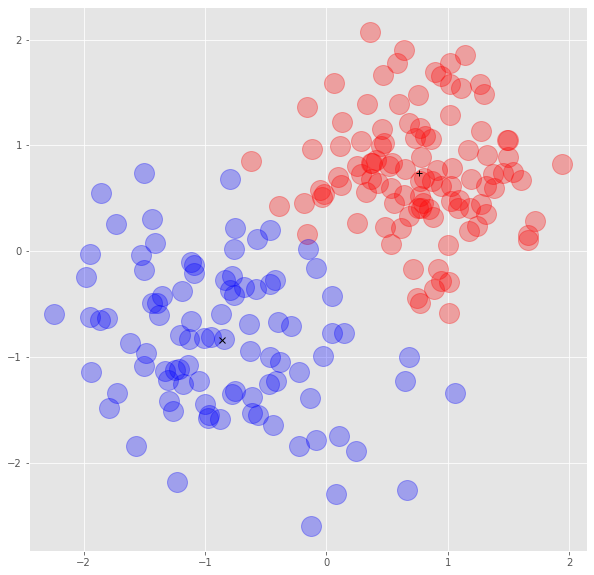

In [15]:
pl.figure(figsize = (10,10))



pl.plot(Xscale[kmeansmod.labels_ == 0][:,0], Xscale[kmeansmod.labels_ == 0][:,1], 'ro', ms=20, alpha = 0.3)
pl.plot(Xscale[kmeansmod.labels_ == 1][:,0], Xscale[kmeansmod.labels_ == 1][:,1],'bo', ms=20, alpha = 0.3)
pl.plot(kmeansmod.cluster_centers_[1,0], kmeansmod.cluster_centers_[1,1], 'kx')
pl.plot(kmeansmod.cluster_centers_[0,0], kmeansmod.cluster_centers_[0,1], 'k+')


    

# w real data

In [16]:
import pandas as pd

In [17]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [18]:
cd /content/drive/Shareddrives/DSPS2021

/content/drive/Shareddrives/DSPS2021


In [19]:
ls

data/


this cell is expected to return an error

In [20]:
pd.read_csv("data/seeds_dataset.txt")

,15.26\t14.84\t0.871\t5.763\t3.312\t2.221\t5.22\t1
0,14.88\t14.57\t0.8811\t5.554\t3.333\t1.018\t4.9...
1,14.29\t14.09\t0.905\t5.291\t3.337\t2.699\t4.82...
2,13.84\t13.94\t0.8955\t5.324\t3.379\t2.259\t4.8...
3,16.14\t14.99\t0.9034\t5.658\t3.562\t1.355\t5.1...
4,14.38\t14.21\t0.8951\t5.386\t3.312\t2.462\t4.9...
...,...
204,12.19\t13.2\t0.8783\t5.137\t2.981\t3.631\t4.87\t3
205,11.23\t12.88\t0.8511\t5.14\t2.795\t4.325\t5.00...
206,13.2\t13.66\t0.8883\t5.236\t3.232\t8.315\t5.05...
207,11.84\t13.21\t0.8521\t5.175\t2.836\t3.598\t5.0...


In [21]:
pd.read_csv("data/seeds_dataset.txt", sep="\t")


ParserError: ignored

In [22]:
pd.read_csv("data/seeds_dataset.txt", sep="\t", usecols=range(8), header=None)

,0,1,2,3,4,5,6,7
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1.0
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1.0
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1.0
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1.0
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1.0
...,...,...,...,...,...,...,...,...
205,12.19,13.20,0.8783,5.137,2.981,3.631,4.870,3.0
206,11.23,12.88,0.8511,5.140,2.795,4.325,5.003,3.0
207,13.20,13.66,0.8883,5.236,3.232,8.315,5.056,3.0
208,11.84,13.21,0.8521,5.175,2.836,3.598,5.044,3.0


In [23]:
seeds = pd.read_csv("data/seeds_dataset.txt", header=None, sep="\t", usecols=np.arange(8))
seeds["labels"] = 0
for i in range(3):
  seeds["labels"].loc[0+70*i:69+70*i] = 0+i

/usr/local/lib/python3.7/dist-packages/pandas/core/indexing.py:670: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  iloc._setitem_with_indexer(indexer, value)


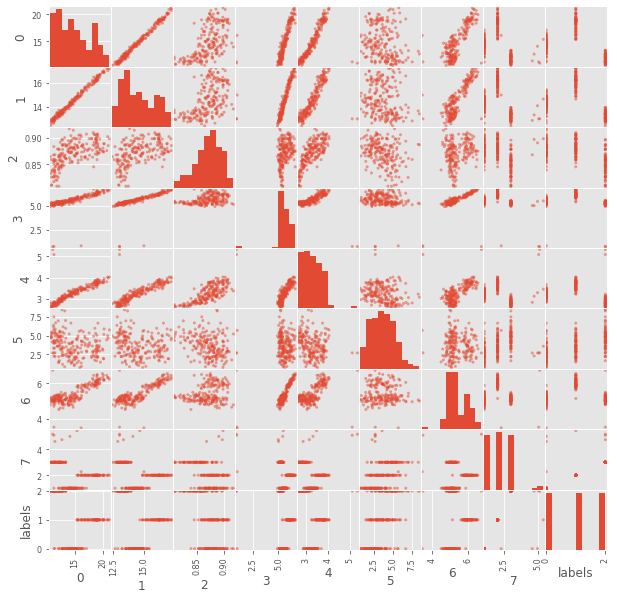

In [24]:
pd.plotting.scatter_matrix(seeds, figsize=(10,10));

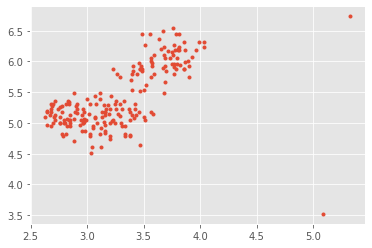

In [25]:
pl.plot(seeds[4], seeds[6], '.')

In [26]:
seeds.dropna(inplace=True, subset=[4,6])
X = np.vstack([seeds[4], seeds[6]]).T
Xscale = sklearn.preprocessing.scale(X, axis=0)
Xscale.shape

(205, 2)

In [27]:

np.isnan(Xscale).sum()

0

In [28]:
kmeansmod  = sklearn.cluster.KMeans(n_clusters=2).fit(Xscale)

In [29]:
Xscale.mean(axis=0)

array([ 8.66515531e-16, -1.27594412e-15])

In [30]:
kmeansmod.labels_

array([0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0], dtype=int32)

In [31]:
kmeansmod.cluster_centers_

array([[-0.54155207, -0.65575223],
       [ 0.97924484,  1.18574375]])

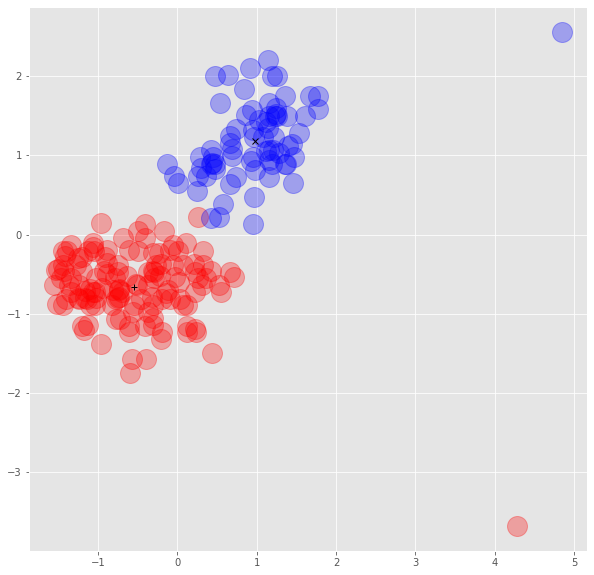

In [32]:
pl.figure(figsize = (10,10))


pl.plot(Xscale[kmeansmod.labels_ == 0][:,0], Xscale[kmeansmod.labels_ == 0][:,1], 'ro', ms=20, alpha = 0.3)
pl.plot(Xscale[kmeansmod.labels_ == 1][:,0], Xscale[kmeansmod.labels_ == 1][:,1],'bo', ms=20, alpha = 0.3)
#pl.plot(Xscale[kmeansmod.labels_ == 2][:,0], Xscale[kmeansmod.labels_ == 2][:,1],'yo', ms=20, alpha = 0.3)
#pl.plot(kmeansmod.cluster_centers_[2,0], kmeansmod.cluster_centers_[2,1], 'ks')
pl.plot(kmeansmod.cluster_centers_[1,0], kmeansmod.cluster_centers_[1,1], 'kx')
pl.plot(kmeansmod.cluster_centers_[0,0], kmeansmod.cluster_centers_[0,1], 'k+')


    

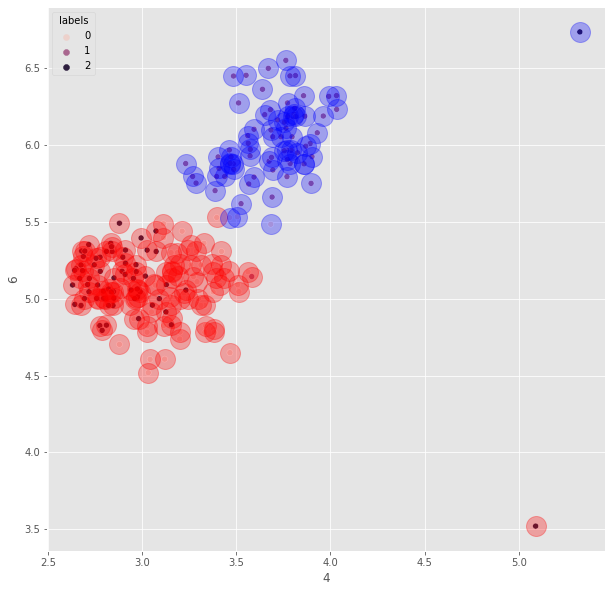

In [33]:
import seaborn as sns

pl.figure(figsize = (10,10))
sns.scatterplot(data=seeds, x=4, y=6, hue="labels")


pl.plot(X[kmeansmod.labels_ == 0][:,0], X[kmeansmod.labels_ == 0][:,1], 'ro', ms=20, alpha = 0.3)
pl.plot(X[kmeansmod.labels_ == 1][:,0], X[kmeansmod.labels_ == 1][:,1],'bo', ms=20, alpha = 0.3)
pl.plot(X[kmeansmod.labels_ == 2][:,0], X[kmeansmod.labels_ == 2][:,1], 'yo', ms=20, alpha = 0.3)


NOTE: K-means does not have the concept of "outliers" for that you need DBScan (see slides)